In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/6 oultiler removed last visulaization.csv")

In [ ]:
df

,society_name,price,City,sqft,furnished_status,bhk
0,Godrej Ivara,30900000.0,Pune,1550,Unfurnished,4.0
1,Majestique Evolvus,24200000.0,Pune,1684,Unfurnished,4.0
2,Rachana Bella Casa Royale,15300000.0,Pune,1166,Unfurnished,3.0
3,Nyati Emerald,17500000.0,Pune,1213,Unfurnished,3.0
4,Lodha Massimo,78400000.0,Pune,3673,Unfurnished,5.0
...,...,...,...,...,...,...
749,Sterling Villa Grande,72000000.0,Bangalore,3500,Unfurnished,3.0
750,Prestige Silver Oak,72000000.0,Bangalore,4144,Unfurnished,4.0
751,Raffles Park,105500000.0,Bangalore,6420,Unfurnished,5.0
752,Urban Poetry Of Earth,42200000.0,Bangalore,3512,Unfurnished,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   society_name      754 non-null    object 
 1   price             754 non-null    float64
 2   City              754 non-null    object 
 3   sqft              754 non-null    int64  
 4   furnished_status  754 non-null    object 
 5   bhk               754 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 35.5+ KB


In [ ]:
df.groupby(['City',"bhk"])['price'].median()

City       bhk 
Ahmedabad  2.0       5100000.0
           3.0       8655000.0
           4.0      28000000.0
           5.0      32200000.0
           6.0      61000000.0
Bangalore  1.0       9100000.0
           2.0      16900000.0
           3.0      27600000.0
           4.0      48400000.0
           5.0      98350000.0
Chennai    2.0      11500000.0
           3.0      15100000.0
           4.0      42900000.0
Delhi      3.0      28500000.0
           4.0     101900000.0
           5.0     133450000.0
Gurgaon    2.0      15000000.0
           3.0      27500000.0
           4.0      38500000.0
           5.0      62500000.0
Hyderabad  2.0      12950000.0
           3.0      20550000.0
           4.0      47200000.0
           5.0      90750000.0
Kolkata    2.0       6850000.0
           3.0      16000000.0
           4.0      26850000.0
           5.0      48400000.0
Mumbai     1.0       8500000.0
           2.0      23500000.0
           3.0      73850000.0
           4.0     143800000.0
           5.0     204400000.0
           6.0      72100000.0
           7.0      91400000.0
           10.0    500000000.0
Noida      3.0      19350000.0
           4.0      65000000.0
Pune       1.0       4600000.0
           2.0       9105000.0
           3.0      21500000.0
           4.0      24100000.0
           5.0      65800000.0
           6.0      66600000.0
Name: price, dtype: float64

##**Univariate Analysis**

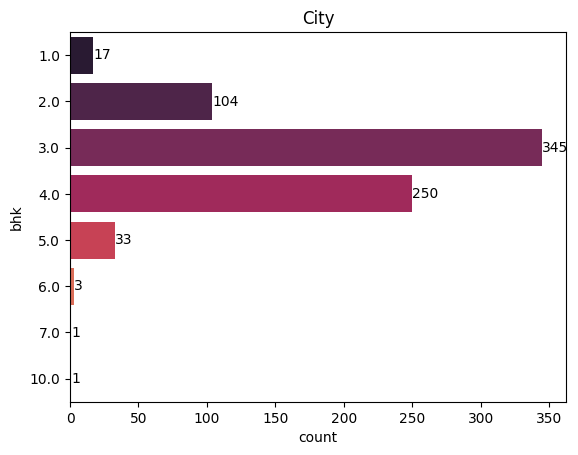

In [ ]:
#sns.countplot(df['City'])
a=sns.countplot(y='bhk', data=df, palette='rocket')
for i in a.containers:
    a.bar_label(i)
plt.title("City")
plt.show()

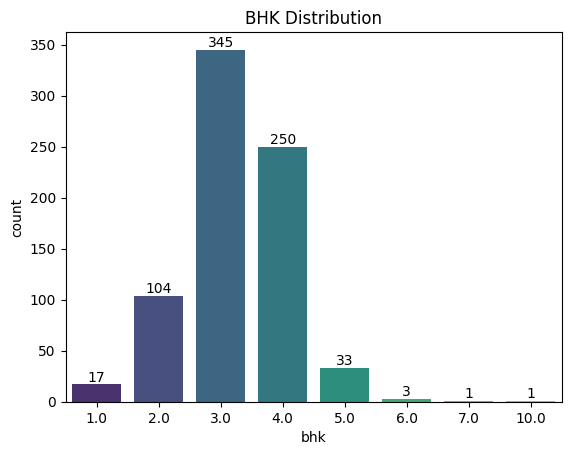

In [ ]:
a=sns.countplot(x='bhk', data=df, palette='viridis')
for i in a.containers:
    a.bar_label(i)
plt.title("BHK Distribution")
plt.show()

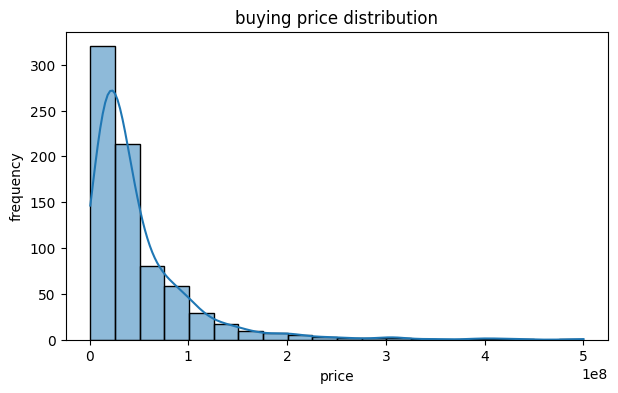

In [ ]:
plt.figure(figsize = (7,4))
sns.histplot(df['price'],kde = True,bins=20)
plt.title('buying price distribution')
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

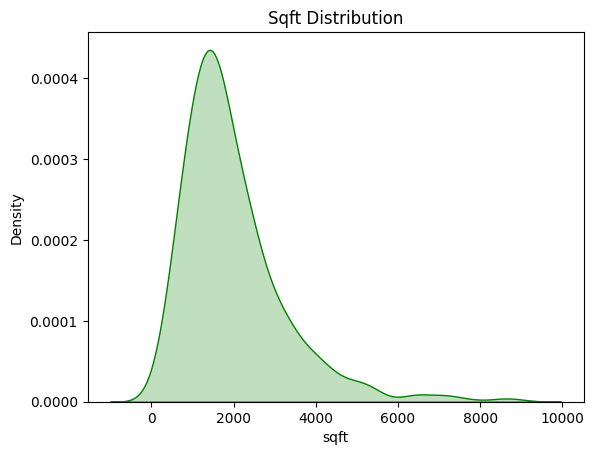

In [ ]:
a=sns.kdeplot(x='sqft', data=df,fill = True, color = 'green')
for i in a.containers:
    a.bar_label(i)
plt.title("Sqft Distribution")
plt.show()

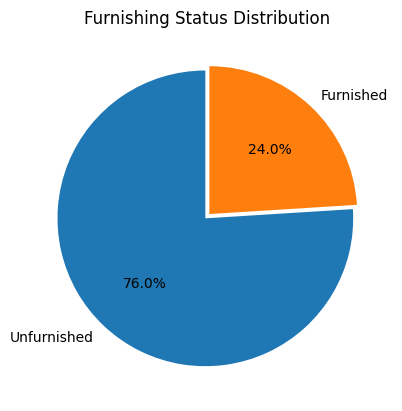

In [ ]:
df['furnished_status'].value_counts().plot(kind='pie', autopct='%1.1f%%',startangle=90,explode=[0.02]*df['furnished_status'].nunique())
plt.title("Furnishing Status Distribution")
plt.ylabel('')
plt.show()

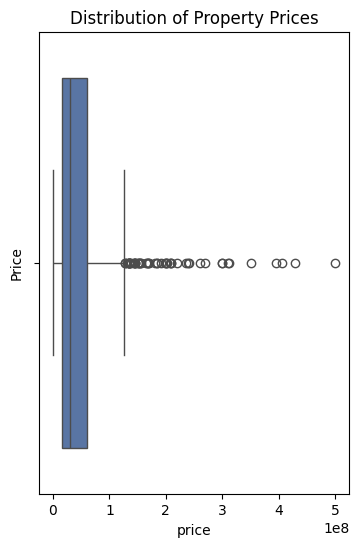

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(x=df['price'], palette= 'deep')

plt.title('Distribution of Property Prices')
plt.ylabel('Price')
plt.show()


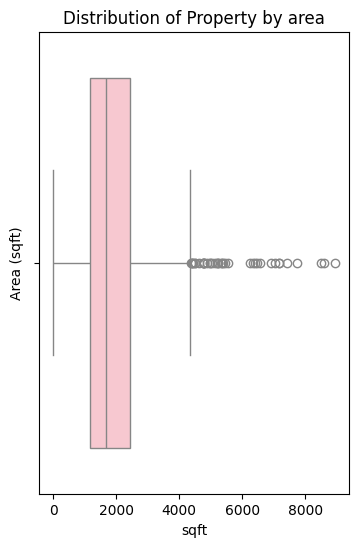

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(x=df['sqft'], color='pink')

plt.title('Distribution of Property by area')
plt.ylabel('Area (sqft)')
plt.show()

##**Bivariate Analysys**

[]

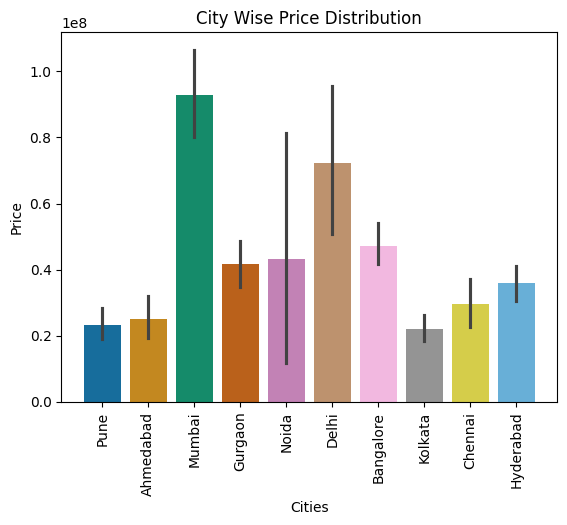

In [ ]:
sns.barplot(x = 'City', y = 'price',data = df,palette='colorblind')
plt.title('City Wise Price Distribution')
plt.xlabel('Cities')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.plot()

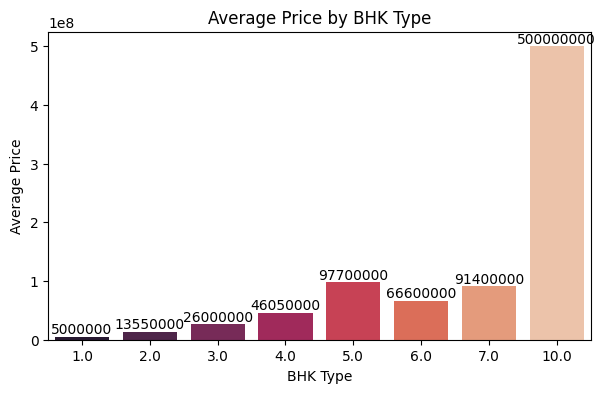

In [ ]:
avg_rent_bhk = df.groupby('bhk')['price'].median().reset_index()

plt.figure(figsize=(7,4))
a = sns.barplot(x='bhk', y='price', data=avg_rent_bhk, palette='rocket')

for i in a.containers:
    a.bar_label(i, fmt='%.0f')

plt.title("Average Price by BHK Type")
plt.xlabel("BHK Type")
plt.ylabel("Average Price")
plt.show()

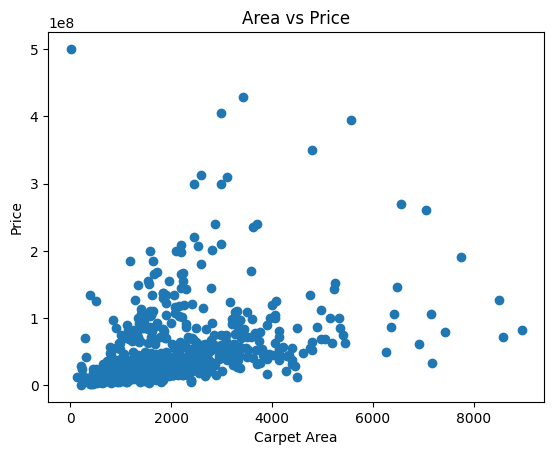

In [ ]:
plt.scatter(df['sqft'], df['price'])
plt.xlabel("Carpet Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

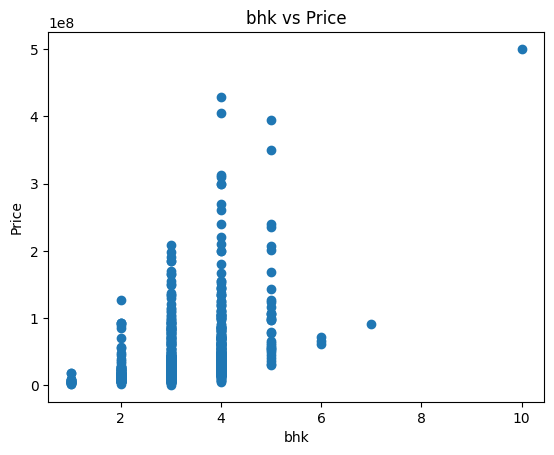

In [ ]:
plt.scatter(df['bhk'], df['price'])
plt.xlabel("bhk")
plt.ylabel("Price")
plt.title("bhk vs Price")
plt.show()

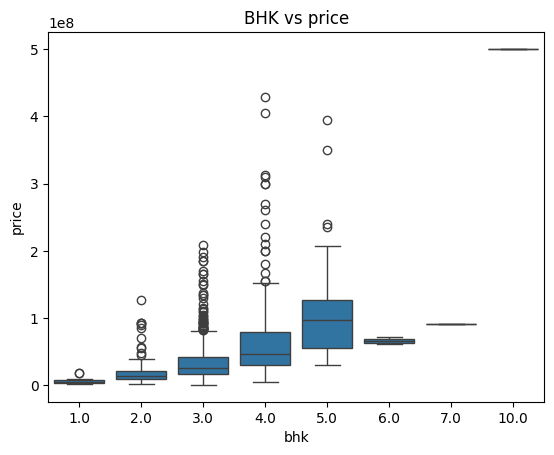

In [ ]:
sns.boxplot(x='bhk', y='price',data = df)
plt.title("BHK vs price")
plt.show()

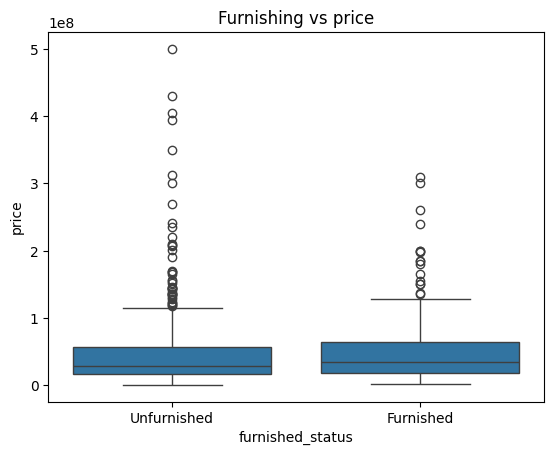

In [ ]:
sns.boxplot(x='furnished_status', y='price', data=df)
plt.title("Furnishing vs price")
plt.show()

##**Mulitvariate Analysis**

<Axes: >

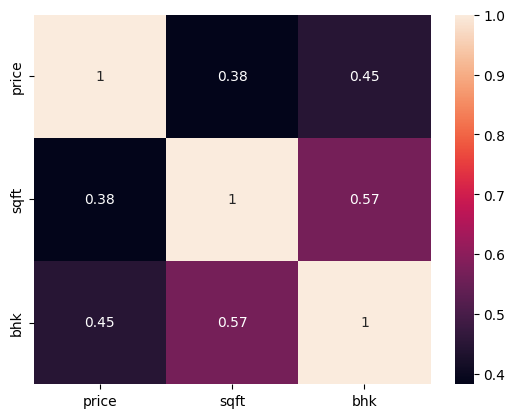

In [ ]:
corr = df.corr(numeric_only = True)

sns.heatmap(corr, annot = True)

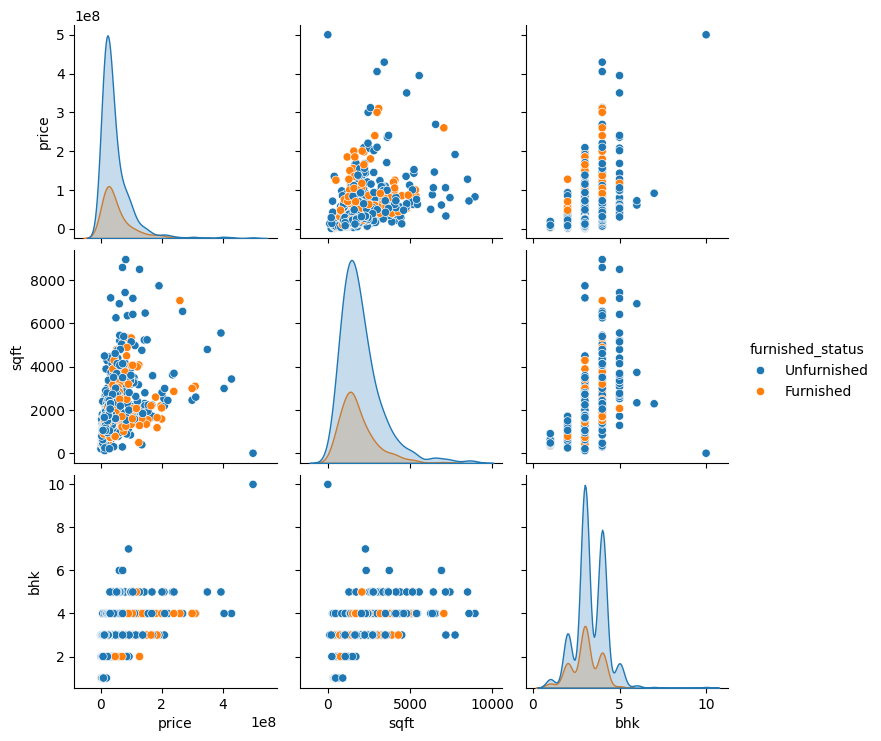

In [ ]:
sns.pairplot(df[['price', 'sqft', 'bhk', 'furnished_status']], hue='furnished_status')
